In [1]:
# /share/storage3/rubin/microlensing/romanrubin/RR2025/Baseline4_set/BH/set_sim1

In [2]:
import logging
import os
import pandas as pd
import requests
import sys
from tqdm import tqdm
from urllib.request import urlretrieve
import numpy as np
import matplotlib.pyplot as plt
import george
from george import kernels
from scipy.optimize import minimize
from astropy.stats import biweight_location
from functools import partial
import logging
from astropy.io import fits
from astropy.stats import biweight_location
from functools import partial
import george
from george import kernels
from matplotlib import pyplot as plt
import numpy as np
from scipy.optimize import minimize


# Logging
logging.basicConfig(stream=sys.stdout)
logger = logging.getLogger("avocado")


# Exceptions
class AvocadoException(Exception):
    """The base class for all exceptions raised in avocado."""

    pass


def _verify_hdf_chunks(store, keys):
    """Verify that a pandas table that was written to an HDF5 file in chunks
    was fully written out.

    If successful, this will return normally. Otherwise, it will raise an
    exception indicating which chunks missing in the file.

    Parameters
    ----------
    store : `pandas.HDFStore`
        The HDF5 file to verify.
    keys : list
        A list of keys to verify in the HDF5 file.
    """
    if "chunk_info" not in store:
        # No chunk_info. The file wasn't written by chunks so there is nothing
        # to do.
        return

    chunk_info = pd.read_hdf(store, "chunk_info")

    missing_chunks = {key: list() for key in keys}

    valid = True

    for chunk_id, chunk_str in chunk_info.itertuples():
        chunk_keys = chunk_str.split(",")

        for key in keys:
            if key not in chunk_keys:
                missing_chunks[key].append(chunk_id)
                valid = False

    if not valid:
        # Missing some keys, raise an exception.
        missing_str = ""
        show_chunks = 5
        for key, chunks in missing_chunks.items():
            if len(chunks) == 0:
                continue

            chunk_str = ", ".join([str(i) for i in chunks[:5]])
            if len(chunks) > show_chunks:
                chunk_str += ", ... (%d total)" % len(chunks)
            missing_str += "\n    %s: %s" % (key, chunk_str)

        message = "File %s is missing the following chunks: %s" % (
            store.filename,
            missing_str,
        )

        raise AvocadoException(message)


def _map_column_name(key_store, target_name):
    """Figure out the internal column name for a given target name

    If a column is used as the index of a table, its PyTables name is 'index'
    instead of the desired name. Handle that gracefully.
    """
    try:
        index_name = key_store.attrs.info["index"]["index_name"]
    except KeyError:
        index_name = ""

    if index_name == target_name:
        return "index"
    else:
        return target_name


def read_dataframes(
    path,
    keys,
    chunk=None,
    num_chunks=None,
    chunk_column="object_id",
    verify_input_chunks=True,
):
    """Read a set of pandas DataFrames from an HDF5 file

    Optionally, the DataFrames can be read in chunks. If that is the case, the
    column specified by `chunk_column` will be loaded from the DataFrame
    corresponding to the first key in keys. This column will be sorted, and
    split into `num_chunks` equal length chunks. Only the data from the chunk
    specified by `chunk` will be loaded. For all other keys, only rows with a
    matching value of `chunk_column` to the ones selected for the chunk will be
    loaded.

    When reading in chunks, all DataFrames must have the key 'chunk_column'
    available. The first DataFrame must have that column indexed.

    Files can also be written by chunks with `write_dataframe`. When loading
    such a file, we check to make sure that the data for all chunks was
    successfully written, and we raise an exception if chunks are missing. This
    behavior can be overruled by setting `verify_input_chunks` to False.

    Parameters
    ----------
    path : str
        The input file path
    keys : list
        A list of keys to read each DataFrame from in the HDF5 file.
    chunk : int (optional)
        If set, the dataset will be loaded in chunks. This specifies the chunk
        number.
    num_chunks : int (optional)
        If loading the dataset in chunks, this is the total number of chunks to
        use.
    chunk_column : str (optional)
        The column to use for separating chunks.
    verify_input_chunks : bool (optional)
        If True, and the input file was written in chunks, this will verify
        that all chunks are available for the input file.

    Returns
    -------
    dataframes : list
        The list of :class:`pandas.DataFrame` objects that were read.
    """
    store = pd.HDFStore(path, "r")

    # If the input was written in chunks, verify that they are all available.
    if verify_input_chunks:
        _verify_hdf_chunks(store, keys)

    if chunk is None:
        # Not loading in chunks, just load all of the datasets normally.
        dataframes = []
        for key in keys:
            dataframe = pd.read_hdf(store, key)
            dataframe.sort_index(inplace=True)
            dataframes.append(dataframe)
        store.close()
        return dataframes

    # Load a chunk of the dataset.

    if num_chunks is None:
        store.close()
        raise AvocadoException(
            "num_chunks must be specified to load the data in chunks!"
        )

    if chunk < 0 or chunk >= num_chunks:
        store.close()
        raise AvocadoException("chunk must be in range [0, num_chunks)!")

    first = True

    dataframes = []

    for key in keys:
        key_store = store.get_storer(key)
        use_name = _map_column_name(key_store, chunk_column)

        if first:
            # Use the first DataFrame to figure out the range of values of the
            # chunk column that we want to load.

            # Need to make sure that there is a CSI index for this column (one
            # that is fully sorted). If not, we can't use these tricks.
            # Calling `write_dataframe` with index_chunk_column=True ensures
            # that the chunk_column has a CSI index.
            index = key_store.table.colindexes[use_name]
            if not index.is_csi:
                raise AvocadoException(
                    "Error: can only do chunking on columns with a CSI index!"
                )

            # Use inclusive start and end indices and figure out the rows at
            # those boundaries.
            num_rows = index.nelements
            start_idx = chunk * num_rows // num_chunks
            end_idx = (chunk + 1) * num_rows // num_chunks - 1

            start_object_id = index.read_sorted(start_idx, start_idx + 1)[0]
            end_object_id = index.read_sorted(end_idx, end_idx + 1)[0]

            start_object_id = start_object_id.decode().strip()
            end_object_id = end_object_id.decode().strip()

            first = False

        # Read the DataFrame
        match_str = "(%s >= '%s') & (%s <= '%s')" % (
            use_name,
            start_object_id,
            use_name,
            end_object_id,
        )
        dataframe = pd.read_hdf(store, key, where=match_str)
        dataframe.sort_index(inplace=True)

        dataframes.append(dataframe)

    store.close()
    return dataframes


def read_dataframes_query(path, keys, query_key, query_column='object_id'):
    """Read a set of pandas DataFrames for rows in an HDF5 matching a given query.

    This is primarily used to read the observations for a single object without
    having to load all of the other objects. To do this, pass the object ID as
    `query_key`.

    Parameters
    ----------
    path : str
        Input file path
    keys : list
        A list of keys to read each DataFrame from in the HDF5 file.
    query_key : str
        Key to query for.
    query_column : str
        Column that the key is in.

    Returns
    -------
    dataframes : list
        The list of :class:`pandas.DataFrame` objects that were read.
    """
    store = pd.HDFStore(path, "r")

    dataframes = []

    for key in keys:
        key_store = store.get_storer(key)
        use_query_column = _map_column_name(key_store, query_column)
        match_str = f"{use_query_column} == {query_key}"
        dataframe = pd.read_hdf(store, key, where=match_str)
        dataframe.sort_index(inplace=True)
        dataframes.append(dataframe)

    store.close()
    return dataframes


def write_dataframe(
    path,
    dataframe,
    key,
    overwrite=False,
    append=None,
    timeout=5,
    chunk=None,
    num_chunks=None,
    chunk_column="object_id",
    index_chunk_column=True,
):
    """Write a dataframe out to an HDF5 file

    The append functionality is designed so that multiple independent
    processes, potentially running simultaneously, can append to the same file.
    Each process will lock the output file while it is writing, and other
    processes will repeatedly try to get the lock until they succeed. With this
    implementation, if the file is locked by other means, the processes will
    hang endlessly until the lock is released.

    Typically, the append functionality is used when the writing process is
    operating on an input file with multiple chunks. If "chunk" and
    "num_chunks" are passed, then this writer keeps track of which chunks have
    been processed and which haven't. `read_dataframes` will then be able to
    tell if it is reading a complete file or not.

    Parameters
    ----------
    path : str
        The output file path.
    dataframe : :class:`pandas.DataFrame`
        The pandas DataFrame object to write out.
    key : str
        The key to write the DataFrame out to.
    overwrite : bool
        If there is an existing file at the given path, it will be deleted if
        overwrite is True. Otherwise an exception will be raised. overwrite is
        not supported if using the append functionality.
    append : bool
        If True, the dataframe will be appended to the file if a file exists at
        the given path. defualt: True if chunk is set, False otherwise.
    timeout : int
        After failing to write to a file in append mode, wait this amount of
        time in seconds before retrying the write (to allow other processes to
        finish).
    chunk : int (optional)
        If the dataset was loaded in chunks, this indicates the chunk number.
    num_chunks : int (optional)
        If the dataset was loaded in chunks, this is the total number of chunks
        used.
    chunk_column : str (optional)
        If the dataset was loaded in chunks, this is the column that was used
        for separating chunks.
    index_chunk_column : bool (optional)
        If True (default), create a PyTables CSI index on the chunk column.
        This is necessary for us to be able to choose chunks of the dataset
        without having to read everything at once. The index can be created
        later with `_create_csi_index` after the DataFrame has fully been
        written to disk if necessary.
    """
    from tables.exceptions import HDF5ExtError
    import time

    if append is None:
        if chunk is not None:
            append = True
        else:
            append = False

    # Make the containing directory if it doesn't exist yet.
    directory = os.path.dirname(path)
    os.makedirs(directory, exist_ok=True)

    # Handle if the file already exists.
    if os.path.exists(path):
        if overwrite:
            logger.warning("Overwriting %s..." % path)
            os.remove(path)
        elif append:
            # We are appending to the file, so it is fine to have a file
            # there already.
            pass
        else:
            raise AvocadoException("Dataset %s already exists! Can't write." % path)

    # Get a lock on the HDF5 file.
    while True:
        try:
            store = pd.HDFStore(path, "a")
        except HDF5ExtError:
            # Failed to get a lock on the file. If we are in append mode,
            # another process likely has the lock already, so wait and try
            # again. If we aren't in append mode, this shouldn't happen.
            if not append:
                raise

            logger.info(
                "Couldn't get lock for HDF5 file %s... another process is "
                "probably using it. Retrying in %d seconds." % (path, timeout)
            )

            time.sleep(timeout)
        else:
            # Got the lock successfully.
            break

    # If we are writing out chunks, make sure that this chunk hasn't already
    # been written to this file.
    if chunk is not None:
        if "chunk_info" in store:
            chunk_info = pd.read_hdf(store, "chunk_info")
        else:
            # No chunk_info yet, create it.
            chunk_index = [i for i in range(num_chunks)]
            chunk_values = ["" for i in range(num_chunks)]
            chunk_info = pd.DataFrame({"keys": chunk_values}, index=chunk_index)

        # Make sure that the chunk_info has the right number of chunks.
        file_num_chunks = len(chunk_info)
        if file_num_chunks != num_chunks:
            raise AvocadoException(
                "Mismatched number of chunks (current %d, requested %d) "
                "for file %s." % (file_num_chunks, num_chunks, path)
            )

        # Make sure that we haven't already written any of the keys.
        written_keys = chunk_info.loc[chunk, "keys"].split(",")

        if key in written_keys:
            raise AvocadoException(
                "Error writing %s! Already found key %s for chunk %d!"
                % (path, key, chunk)
            )

        written_keys.append(key)

        # Remove the empty key that is created the first time around.
        if "" in written_keys:
            written_keys.remove("")

        # Update the written keys with the ones that we are adding.
        chunk_info.loc[chunk, "keys"] = ",".join(written_keys)
        chunk_info.to_hdf(store, "chunk_info", format="table")

    dataframe.to_hdf(
        store, key, mode="a", append=append, format="table", data_columns=[chunk_column]
    )

    if index_chunk_column:
        _create_csi_index(store, key, chunk_column)

    store.close()


def _create_csi_index(store, key, column_name):
    """Create a CSI index on a column in an HDF5 file.

    The column must have been already specified in the data_columns call to
    to_hdf or it won't be stored correctly in the HDF5 file.

    Parameters
    ----------
    store : :class:`pandas.HDFStore`
        An HDF5 file opened as an instance of a :class:`pandas.HDFStore`
        object.
    key : str
        The key of the DataFrame to use.
    column_name : str
        The column to add a CSI index to.
    """
    key_store = store.get_storer(key)
    use_name = _map_column_name(key_store, column_name)
    column = key_store.table.colinstances[use_name]

    if not column.index.is_csi:
        column.remove_index()
        column.create_csindex()


def read_dataframe(path, key, *args, **kwargs):
    """Read a single DataFrame out to an HDF5 file

    This is just a thin wrapper around read_dataframes.
    """
    return read_dataframes(path, [key], **kwargs)[0]


def download_file(url, path, filesize=None):
    """Download a file with a tqdm progress bar. This code is adapted from an
    example in the tqdm documentation.
    """
    # Check if the file already exists, and don't download it if it does.
    if os.path.exists(path):
        # Make sure that we have a full download
        if filesize is None or os.path.getsize(path) == filesize:
            print("Skipping %s, already exists." % os.path.basename(path))
            return
        else:
            print("Found incomplete download of %s, retrying." %
                  os.path.basename(path))
            os.remove(path)

    class TqdmUpTo(tqdm):
        """Provides `update_to(n)` which uses `tqdm.update(delta_n)`."""
        def update_to(self, b=1, bsize=1, tsize=None):
            """
            b  : int, optional
                Number of blocks transferred so far [default: 1].
            bsize  : int, optional
                Size of each block (in tqdm units) [default: 1].
            tsize  : int, optional
                Total size (in tqdm units). If [default: None] remains unchanged.
            """
            if tsize is not None:
                self.total = tsize
            self.update(b * bsize - self.n)  # will also set self.n = b * bsize

    with TqdmUpTo(unit='B', unit_scale=True, miniters=1,
                  desc=url.split('/')[-1]) as t:  # all optional kwargs
        urlretrieve(url, filename=path, reporthook=t.update_to, data=None)


def download_zenodo(record, basedir):
    # Make the download directory if it doesn't exist.
    os.makedirs(basedir, exist_ok=True)

    # Download a dataset from zenodo.
    zenodo_url = f"https://zenodo.org/api/records/{record}"
    zenodo_metadata = requests.get(zenodo_url).json()

    for file_metadata in zenodo_metadata['files']:
        path = os.path.join(basedir, file_metadata['key'])
        url = file_metadata['links']['self']
        filesize = file_metadata['size']

        download_file(url, path, filesize)

In [3]:
band_central_wavelengths = {
    "u": 3671.0,
    "g": 4827.0,
    "r": 6223.0,
    "i": 7546.0,
    "z": 8691.0,
    "Y": 9710.0,

    "ps1::g": 4866.0,
    "ps1::r": 6214.6,
    "ps1::i": 7544.6,
    "ps1::z": 8679.5,

    "desg": 4686.,
    "desr": 6166.,
    "desi": 7480.,
    "desz": 8932.,

    "ztfg": 4813.9,
    "ztfr": 6421.8,
    "ztfi": 7883.0,

    "uvot::u": 3475.5,
    "uvot::b": 4359.0,
    "uvot::v": 5430.1,
    "uvot::uvm2": 2254.9,
    "uvot::uvw1": 2614.1,
    "uvot::uvw2": 2079.0,
}

# Colors for plotting
band_plot_colors = {
    "u": "C6",
    "g": "C4",
    "r": "C0",
    "i": "C2",
    "z": "C3",
    "Y": "goldenrod",

    "ps1::g": "C0",
    "ps1::r": "C2",
    "ps1::i": "C1",
    "ps1::z": "C3",

    "desg": "C4",
    "desr": "C0",
    "desi": "C2",
    "desz": "C3",

    "ztfg": "C0",
    "ztfr": "C2",
    "ztfi": "C1",
}

# Markers for plotting
band_plot_markers = {
    "u": "o",
    "g": "v",
    "r": "^",
    "i": "<",
    "z": ">",
    "Y": "s",

    "ps1::g": "o",
    "ps1::r": "^",
    "ps1::i": "v",
    "ps1::z": "p",

    "desg": "v",
    "desr": "^",
    "desi": "<",
    "desz": ">",

    "ztfg": "o",
    "ztfr": "^",
    "ztfi": "v",
}


def get_band_central_wavelength(band):
    """Return the central wavelength for a given band.

    If the band does not yet have a color assigned to it, an AvocadoException
    is raised.

    Parameters
    ----------
    band : str
        The name of the band to use.
    """
    # print(band)
    if band in band_central_wavelengths:
        return band_central_wavelengths[band]
    else:
        raise AvocadoException(
            "Central wavelength unknown for band %s. Add it to "
            "avocado.instruments.band_central_wavelengths." % band
        )


def get_band_plot_color(band):
    """Return the plot color for a given band.

    If the band does not yet have a color assigned to it, then a random color
    will be assigned (in a systematic way).

    Parameters
    ----------
    band : str
        The name of the band to use.
    """
    if band in band_plot_colors:
        return band_plot_colors[band]

    print("No plot color assigned for band %s, assigning a random one." % band)

    # Systematic random colors. We use the hash of the band name.
    # Note: hash() uses a random offset in python 3 so it isn't consistent
    # between runs!
    import hashlib

    hasher = hashlib.md5()
    hasher.update(band.encode("utf8"))
    hex_color = "#%s" % hasher.hexdigest()[-6:]

    band_plot_colors[band] = hex_color

    return hex_color


def get_band_plot_marker(band):
    """Return the plot marker for a given band.

    If the band does not yet have a marker assigned to it, then we use the
    default circle.

    Parameters
    ----------
    band : str
        The name of the band to use.
    """
    if band in band_plot_markers:
        return band_plot_markers[band]
    else:
        return "o"

In [4]:
class AstronomicalObject:
    """An astronomical object, with metadata and a lightcurve.

    An astronomical object has both metadata describing its global properties,
    and observations of its light curve.

    Parameters
    ----------
    metadata : dict-like
        Metadata for this object. This is represented using a dict
        internally, and must be able to be cast to a dict. Any keys and
        information are allowed. Various functions assume that the
        following keys exist in the metadata:

        - object_id: A unique ID for the object. This will be stored as a
          string internally.
        - galactic: Whether or not the object is in the Milky Way galaxy or
          not.
        - host_photoz: The photometric redshift of the object's host galaxy.
        - host_photoz_error: The error on the photometric redshift of the
          object's host galaxy.
        - host_specz: The spectroscopic redshift of the object's host galaxy.

        For training data objects, the following keys are assumed to exist in
        the metadata:
        - redshift: The true redshift of the object.
        - class: The true class label of the object.

    observations : pandas.DataFrame
        Observations of the object's light curve. This should be a pandas
        DataFrame with at least the following columns:

        - time: The time of each observation.
        - band: The band used for the observation.
        - flux: The measured flux value of the observation.
        - flux_error: The flux measurement uncertainty of the observation.
    """

    def __init__(self, metadata, observations):
        """Create a new AstronomicalObject"""
        self.metadata = dict(metadata)
        self.observations = observations

        self._default_gaussian_process = None

    def __repr__(self):
        return f"{type(self).__name__}(object_id={self.metadata['object_id']})"

    @property
    def bands(self):
        """Return a list of bands that this object has observations in

        Returns
        -------
        bands : numpy.array
            A list of bands, ordered by their central wavelength.
        """
        unsorted_bands = np.unique(self.observations["band"])
        sorted_bands = np.array(sorted(unsorted_bands, key=get_band_central_wavelength))
        return sorted_bands

    def subtract_background(self):
        """Subtract the background levels from each band.

        The background levels are estimated using a biweight location
        estimator. This estimator will calculate a robust estimate of the
        background level for objects that have short-lived light curves, and it
        will return something like the median flux level for periodic or
        continuous light curves.

        Returns
        -------
        subtracted_observations : pandas.DataFrame
            A modified version of the observations DataFrame with the
            background level removed.
        """
        subtracted_observations = self.observations.copy()

        for band in self.bands:
            mask = self.observations["band"] == band
            band_data = self.observations[mask]

            # Use a biweight location to estimate the background
            ref_flux = biweight_location(band_data["flux"])

            subtracted_observations.loc[mask, "flux"] -= ref_flux

        return subtracted_observations

    def preprocess_observations(self, subtract_background=True, **kwargs):
        """Apply preprocessing to the observations.

        This function is intended to be used to transform the raw observations
        table into one that can actually be used for classification. For now,
        all that this step does is apply background subtraction.

        Parameters
        ----------
        subtract_background : bool (optional)
            If True (the default), a background subtraction routine is applied
            to the lightcurve before fitting the GP. Otherwise, the flux values
            are used as-is.
        kwargs : dict
            Additional keyword arguments. These are ignored. We allow
            additional keyword arguments so that the various functions that
            call this one can be called with the same arguments, even if they
            don't actually use them.

        Returns
        -------
        preprocessed_observations : pandas.DataFrame
            The preprocessed observations that can be used for further
            analyses.
        """
        if subtract_background:
            preprocessed_observations = self.subtract_background()
        else:
            preprocessed_observations = self.observations

        return preprocessed_observations

    def fit_gaussian_process(
        self,
        fix_scale=False,
        verbose=False,
        guess_length_scale=20.0,
        **preprocessing_kwargs
    ):
        """Fit a Gaussian Process model to the light curve.

        We use a 2-dimensional Matern kernel to model the transient. The kernel
        width in the wavelength direction is fixed. We fit for the kernel width
        in the time direction as different transients evolve on very different
        time scales.

        Parameters
        ----------
        fix_scale : bool (optional)
            If True, the scale is fixed to an initial estimate. If False
            (default), the scale is a free fit parameter.
        verbose : bool (optional)
            If True, output additional debugging information.
        guess_length_scale : float (optional)
            The initial length scale to use for the fit. The default is 20
            days.
        preprocessing_kwargs : kwargs (optional)
            Additional preprocessing arguments that are passed to
            `preprocess_observations`.

        Returns
        -------
        gaussian_process : function
            A Gaussian process conditioned on the object's lightcurve. This is
            a wrapper around the george `predict` method with the object flux
            fixed.
        gp_observations : pandas.DataFrame
            The processed observations that the GP was fit to. This could have
            effects such as background subtraction applied to it.
        gp_fit_parameters : list
            A list of the resulting GP fit parameters.
        """
        gp_observations = self.preprocess_observations(**preprocessing_kwargs)

        fluxes = gp_observations["flux"]
        flux_errors = gp_observations["flux_error"]

        wavelengths = gp_observations["band"].map(get_band_central_wavelength)
        times = gp_observations["time"]

        # Use the highest signal-to-noise observation to estimate the scale. We
        # include an error floor so that in the case of very high
        # signal-to-noise observations we pick the maximum flux value.
        signal_to_noises = np.abs(fluxes) / np.sqrt(
            flux_errors ** 2 + (1e-2 * np.max(fluxes)) ** 2
        )
        scale = np.abs(fluxes[signal_to_noises.idxmax()])

        kernel = (0.5 * scale) ** 2 * kernels.Matern32Kernel(
            [guess_length_scale ** 2, 6000 ** 2], ndim=2
        )

        if fix_scale:
            kernel.freeze_parameter("k1:log_constant")
        kernel.freeze_parameter("k2:metric:log_M_1_1")

        gp = george.GP(kernel)

        guess_parameters = gp.get_parameter_vector()

        if verbose:
            print(kernel.get_parameter_dict())

        x_data = np.vstack([times, wavelengths]).T

        gp.compute(x_data, flux_errors)

        def neg_ln_like(p):
            gp.set_parameter_vector(p)
            return -gp.log_likelihood(fluxes)

        def grad_neg_ln_like(p):
            gp.set_parameter_vector(p)
            return -gp.grad_log_likelihood(fluxes)

        bounds = [(0, np.log(1000 ** 2))]
        if not fix_scale:
            bounds = [(guess_parameters[0] - 10, guess_parameters[0] + 10)] + bounds

        fit_result = minimize(
            neg_ln_like, gp.get_parameter_vector(), jac=grad_neg_ln_like, bounds=bounds
        )

        if fit_result.success:
            gp.set_parameter_vector(fit_result.x)
        else:
            # Fit failed. Print out a warning, and use the initial guesses for
            # fit parameters. This only really seems to happen for objects
            # where the lightcurve is almost entirely noise.
            logger.warn(
                "GP fit failed for %s! Using guessed GP parameters. "
                "This is usually OK." % self
            )
            gp.set_parameter_vector(guess_parameters)

        if verbose:
            print(fit_result)
            print(kernel.get_parameter_dict())

        # Return the Gaussian process and associated data.
        gaussian_process = partial(gp.predict, fluxes)

        return gaussian_process, gp_observations, fit_result.x

    def get_default_gaussian_process(self):
        """Get the default Gaussian Process.

        This method calls fit_gaussian_process with the default arguments and
        caches its output so that multiple calls only require fitting the GP a
        single time.
        """
        if self._default_gaussian_process is None:
            gaussian_process, _, _ = self.fit_gaussian_process()
            self._default_gaussian_process = gaussian_process

        return self._default_gaussian_process

    def predict_gaussian_process(
        self, bands, times, uncertainties=True, fitted_gp=None, **gp_kwargs
    ):
        """Predict the Gaussian process in a given set of bands and at a given
        set of times.

        Parameters
        ==========
        bands : list(str)
            bands to predict the Gaussian process in.
        times : list or numpy.array of floats
            times to evaluate the Gaussian process at.
        uncertainties : bool (optional)
            If True (default), the GP uncertainties are computed and returned
            along with the mean prediction. If False, only the mean prediction
            is returned.
        fitted_gp : function (optional)
            By default, this function will perform the GP fit before doing
            predictions. If the GP fit has already been done, then the fitted
            GP function (returned by fit_gaussian_process) can be passed here
            instead to skip redoing the fit.
        gp_kwargs : kwargs (optional)
            Additional arguments that are passed to `fit_gaussian_process`.

        Returns
        =======
        predictions : numpy.array
            A 2-dimensional array with shape (len(bands), len(times))
            containing the Gaussian process mean flux predictions.
        prediction_uncertainties : numpy.array
            Only returned if uncertainties is True. This is an array with the
            same shape as predictions containing the Gaussian process
            uncertainty for the predictions.
        """
        if fitted_gp is not None:
            gp = fitted_gp
        else:
            gp, _, _ = self.fit_gaussian_process(**gp_kwargs)

        # Predict the Gaussian process band-by-band.
        predictions = []
        prediction_uncertainties = []

        for band in bands:
            wavelengths = np.ones(len(times)) * get_band_central_wavelength(band)
            pred_x_data = np.vstack([times, wavelengths]).T
            if uncertainties:
                band_pred, band_pred_var = gp(pred_x_data, return_var=True)
                prediction_uncertainties.append(np.sqrt(band_pred_var))
            else:
                band_pred = gp(pred_x_data, return_cov=False)
            predictions.append(band_pred)

        predictions = np.array(predictions)
        if uncertainties:
            prediction_uncertainties = np.array(prediction_uncertainties)
            return predictions, prediction_uncertainties
        else:
            return predictions

    def plot_light_curve(self, show_gp=True, verbose=False, axis=None, **kwargs):
        """Plot the object's light curve

        Parameters
        ----------
        show_gp : bool (optional)
            If True (default), the Gaussian process prediction is plotted along
            with the raw data.
        verbose : bool (optional)
            If True, print detailed information about the light curve and GP
            fit.
        axis : `matplotlib.axes.Axes` (optional)
            The matplotlib axis to plot to. If None, a new figure will be
            created.
        kwargs : kwargs (optional)
            Additional arguments. If show_gp is True, these are passed to
            `fit_gaussian_process`. Otherwise, these are passed to
            `preprocess_observations`.
        """
        if verbose:
            self.print_metadata()

        if show_gp:
            gp, observations, gp_fit_parameters = self.fit_gaussian_process(
                verbose=verbose, **kwargs
            )
        else:
            observations = self.preprocess_observations(**kwargs)

        # Figure out the times to plot. We go 10% past the edges of the
        # observations.
        min_time_obs = np.min(observations["time"])
        max_time_obs = np.max(observations["time"])
        border = 0.1 * (max_time_obs - min_time_obs)
        min_time = min_time_obs - border
        max_time = max_time_obs + border

        if show_gp:
            pred_times = np.arange(min_time, max_time + 1)

            predictions, prediction_uncertainties = self.predict_gaussian_process(
                self.bands, pred_times, fitted_gp=gp
            )

        if axis is None:
            figure, axis = plt.subplots()

        for band_idx, band in enumerate(self.bands):
            mask = observations["band"] == band
            band_data = observations[mask]
            color = get_band_plot_color(band)
            marker = get_band_plot_marker(band)

            axis.errorbar(
                band_data["time"],
                band_data["flux"],
                band_data["flux_error"],
                fmt="o",
                c=color,
                markersize=6,
                marker=marker,
                label=band,
            )

            if not show_gp:
                continue

            pred = predictions[band_idx]
            axis.plot(pred_times, pred, c=color)
            err = prediction_uncertainties[band_idx]

            if kwargs.get("uncertainties", True):
                # If they were calculated, show uncertainties with a shaded
                # band.
                axis.fill_between(
                    pred_times, pred - err, pred + err, alpha=0.2, color=color
                )

        axis.legend()

        axis.set_xlabel("Time (days)")
        axis.set_ylabel("Flux")
        axis.set_xlim(min_time, max_time)

        axis.figure.tight_layout()

    def print_metadata(self):
        """Print out the object's metadata in a nice format."""
        # Try to print out specific keys in a nice order. If these keys aren't
        # available, then we skip them. The rest of the keys are printed out in
        # a random order afterwards.
        ordered_keys = [
            "object_id",
            "class",
            "galactic",
            "fold",
            "redshift",
            "host_specz",
            "host_photoz",
            "host_photoz_error",
        ]
        for key in ordered_keys:
            if key in self.metadata:
                print("%20s: %s" % (key, self.metadata[key]))

        for key, value in self.metadata.items():
            if key in ordered_keys:
                continue
            print("%20s: %s" % (key, value))

In [5]:
# logger = logging.getLogger(__name__)
# logger.setLevel(logging.WARNING)

In [6]:
filename_head = "/home/anibal-pc/Downloads/FULL_ELASTICC_TRAIN/ELASTICC_TRAIN_uLens-Binary/ELASTICC_TRAIN_NONIaMODEL0-0001_HEAD.FITS.gz"
with fits.open(filename_head) as hdul:
    hdul.info()
    data_head = hdul[1].data
# data_head

Filename: /home/anibal-pc/Downloads/FULL_ELASTICC_TRAIN/ELASTICC_TRAIN_uLens-Binary/ELASTICC_TRAIN_NONIaMODEL0-0001_HEAD.FITS.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      37   (0,)      
  1  Header        1 BinTableHDU    444   134R x 145C   [16A, 16A, 1I, 1D, 1D, 1E, 1I, 1I, 1J, 1J, 1J, 1J, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1I, 1I, 1K, 1I, 1E, 1E, 1E, 1E, 1D, 1D, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1K, 1E, 1K, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1K, 1I, 1E, 1E, 1E, 1E, 1D, 1D, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1K, 1E, 1K, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1J, 32A, 1I, 1I, 8A, 1J, 1J, 1J, 1J, 1J, 1E, 1E, 1E, 1I, 1E, 1K, 1E, 1E, 1D, 1D, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1I]   


In [7]:
filename = "/home/anibal-pc/Downloads/FULL_ELASTICC_TRAIN/ELASTICC_TRAIN_uLens-Binary/ELASTICC_TRAIN_NONIaMODEL0-0001_PHOT.FITS.gz"
with fits.open(filename) as hdul:
    hdul.info()
    data = hdul[1].data
# data#['ZEROPT']

Filename: /home/anibal-pc/Downloads/FULL_ELASTICC_TRAIN/ELASTICC_TRAIN_uLens-Binary/ELASTICC_TRAIN_NONIaMODEL0-0001_PHOT.FITS.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      35   (0,)      
  1  Photometry    1 BinTableHDU     72   26677R x 21C   [1D, 2A, 1I, 12A, 1J, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E]   


In [8]:

indx = np.where(data['MJD'] == -777)[0]
indices = np.concatenate([np.array([0]),indx])
indices

array([    0,   215,   413,   613,   827,   982,  1178,  1385,  1585,
        1785,  1985,  2191,  2375,  2577,  2739,  2936,  3144,  3343,
        3559,  3757,  3971,  4175,  4381,  4575,  4772,  4961,  5169,
        5361,  5551,  5756,  5949,  6145,  6341,  6556,  6760,  6951,
        7120,  7324,  7533,  7733,  7932,  8141,  8356,  8569,  8765,
        8958,  9166,  9354,  9554,  9734,  9940, 10151, 10367, 10563,
       10743, 10940, 11142, 11345, 11541, 11735, 11921, 12115, 12309,
       12503, 12728, 12909, 13110, 13313, 13500, 13699, 13899, 14095,
       14283, 14492, 14693, 14886, 15080, 15288, 15418, 15620, 15800,
       15986, 16190, 16400, 16609, 16809, 17026, 17214, 17416, 17596,
       17803, 18035, 18232, 18427, 18627, 18816, 19010, 19195, 19409,
       19609, 19803, 20000, 20219, 20424, 20628, 20849, 21069, 21226,
       21429, 21632, 21843, 22048, 22216, 22412, 22620, 22821, 23026,
       23234, 23433, 23620, 23805, 24002, 24206, 24400, 24613, 24842,
       25049, 25275,

In [9]:

metadata = {"object_id": "test_ulens1",
    "galactic": True,
    "host_photoz": 0.4,
    "host_photoz_error": 0.05,
    "host_specz": 0.42,
    "redshift": 0.4,
    "class": "Binary_ulens"}

i=3
observations = pd.DataFrame({
    "time": data['MJD'][indices[i]+1:indices[i+1]].astype("float64"),
    "band": pd.Series(data['BAND'][indices[i]+1:indices[i+1]].astype(str)).str.strip(),
    "flux": data['FLUXCAL'][indices[i]+1:indices[i+1]].astype("float64"),
    "flux_error": data['FLUXCALERR'][indices[i]+1:indices[i+1]].astype("float64")})

obj = AstronomicalObject(metadata, observations)

           object_id: test_ulens1
               class: Binary_ulens
            galactic: True
            redshift: 0.4
          host_specz: 0.42
         host_photoz: 0.4
   host_photoz_error: 0.05
OrderedDict({'k1:log_constant': np.float64(12.675889397475643), 'k2:metric:log_M_0_0': np.float64(5.991464547107982)})
  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 1207.010869801162
        x: [ 1.074e+01  6.051e+00]
      nit: 9
      jac: [-5.808e-05  5.666e-05]
     nfev: 14
     njev: 14
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>
OrderedDict({'k1:log_constant': np.float64(10.742874334143227), 'k2:metric:log_M_0_0': np.float64(6.050620549616644)})


/tmp/ipykernel_6881/2955804793.py:360: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  axis.errorbar(


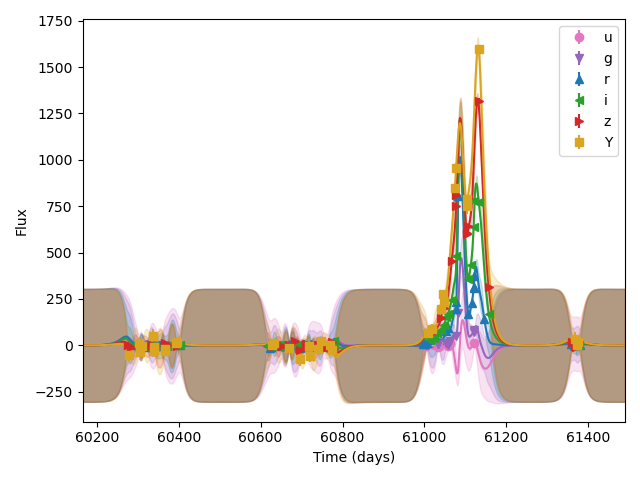

In [10]:
%matplotlib widget
obj.plot_light_curve(show_gp=True, verbose=True)